Customer Churn — Multicollinearity Practical


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

 1. Load Customer Churn Dataset


In [2]:
from pathlib import Path

FILE_PATH = "customer_dataset.csv"

path = Path(FILE_PATH)

if not path.exists():
    raise FileNotFoundError(
        f"CSV file nahi mili: {path.resolve()}\n"
        "Apni Customer Churn CSV ko notebook ke same folder mein rakhein "
        "ya FILE_PATH mein correct path dein."
    )

df = pd.read_csv(path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


## 2. Basic Data Understanding

In [3]:
print("First 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe().T)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes



Data types:


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Missing values:


,missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750


 3. Clean `TotalCharges`


In [4]:
df = df.copy()

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].astype(str).str.strip().replace({"": np.nan}),
        errors="coerce"
    )

print("TotalCharges dtype:", df["TotalCharges"].dtype)

print("\nMissing values after conversion:")
display(df.isna().sum().sort_values(ascending=False).head(10))

# VIF analysis ke liye missing predictor rows remove karenge
df_clean = df.dropna().copy()

print("\nRows before cleaning:", len(df))
print("Rows after cleaning: ", len(df_clean))
print("Rows removed:        ", len(df) - len(df_clean))

TotalCharges dtype: float64

Missing values after conversion:


TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64


Rows before cleaning: 7043
Rows after cleaning:  7032
Rows removed:         11


 4. Separate Target, ID and Predictors


In [5]:
target = df_clean["Churn"].copy() if "Churn" in df_clean.columns else None

X = df_clean.drop(
    columns=["customerID", "CustomerID", "customer_id", "Churn"],
    errors="ignore"
)

print("Predictors:")
print(X.columns.tolist())

print("\nNumerical predictors:")
numeric_X = X.select_dtypes(include=np.number).copy()
print(numeric_X.columns.tolist())

print("\nCategorical predictors:")
categorical_X = X.select_dtypes(
    include=["object", "category", "string"]
).copy()
print(categorical_X.columns.tolist())

Predictors:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Numerical predictors:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical predictors:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Part A — Pairwise Relationship

5. Numerical Correlation Matrix


In [6]:
corr = numeric_X.corr()

display(corr)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000,0.016,0.220,0.102
tenure,0.016,1.000,0.247,0.826
MonthlyCharges,0.220,0.247,1.000,0.651
TotalCharges,0.102,0.826,0.651,1.000


6. Correlation Heatmap

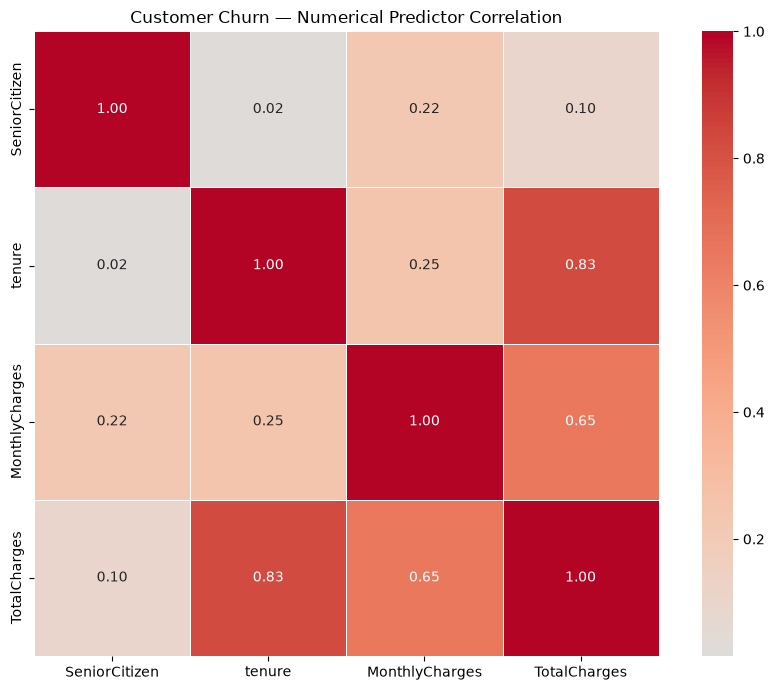

In [7]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Customer Churn — Numerical Predictor Correlation")
plt.tight_layout()
plt.show()

7. Strong Pairwise Correlations


In [8]:
threshold = 0.80

pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]

        if abs(value) >= threshold:
            pairs.append({
                "Feature_1": corr.columns[i],
                "Feature_2": corr.columns[j],
                "Correlation": value
            })

strong_pairs = pd.DataFrame(pairs)

if strong_pairs.empty:
    print(f"No pairwise correlation found with |r| >= {threshold}.")
else:
    strong_pairs["Absolute_Correlation"] = strong_pairs["Correlation"].abs()
    strong_pairs = strong_pairs.sort_values(
        "Absolute_Correlation",
        ascending=False
    ).drop(columns="Absolute_Correlation")

    display(strong_pairs)

,Feature_1,Feature_2,Correlation
0,tenure,TotalCharges,0.826


Part B — VIF

 8. VIF ka Concept












In [16]:
def calculate_vif(X: pd.DataFrame) -> pd.DataFrame:
    X_work = X.replace(
        [np.inf, -np.inf], np.nan
    ).dropna().astype(float)

    constant_cols = [
        col for col in X_work.columns
        if X_work[col].nunique(dropna=False) <= 1
    ]

    if constant_cols:
        X_work = X_work.drop(columns=constant_cols)

    if X_work.shape[1] < 2:
        raise ValueError("VIF ke liye at least 2 predictors chahiye.")

    centered = X_work - X_work.mean()
    standardized = centered / centered.std(ddof=0)
    design = standardized.to_numpy(dtype=float)
    full_rank = np.linalg.matrix_rank(design)

    rows = []

    for i, feature in enumerate(X_work.columns):
        target = design[:, i]
        other_features = np.delete(design, i, axis=1)

        if np.linalg.matrix_rank(other_features) == full_rank:
            vif = np.inf
        else:
            coefficients = np.linalg.lstsq(
                other_features, target, rcond=None
            )[0]
            residual = target - other_features @ coefficients
            residual_ratio = (residual @ residual) / (target @ target)
            vif = 1 / residual_ratio if residual_ratio > 0 else np.inf

        rows.append({
            "Feature": feature,
            "VIF": vif,
            "Tolerance": 1 / vif if np.isfinite(vif) and vif != 0 else 0.0
        })

    return (
        pd.DataFrame(rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


numeric_vif = calculate_vif(numeric_X)

display(numeric_vif)

,Feature,VIF,Tolerance
0,TotalCharges,9.544,0.105
1,tenure,5.847,0.171
2,MonthlyCharges,3.314,0.302
3,SeniorCitizen,1.054,0.948


9. VIF Interpretation


In [10]:
def classify_vif(vif):
    if vif < 2:
        return "Very low"
    elif vif < 5:
        return "Usually acceptable / monitor"
    elif vif < 10:
        return "Investigate"
    else:
        return "Potentially serious"

numeric_vif["Interpretation"] = numeric_vif["VIF"].apply(classify_vif)

display(numeric_vif)

,Feature,VIF,Tolerance,Interpretation
0,TotalCharges,9.544,0.105,Investigate
1,tenure,5.847,0.171,Investigate
2,MonthlyCharges,3.314,0.302,Usually acceptable / monitor
3,SeniorCitizen,1.054,0.948,Very low


Part C — Customer Churn Domain Case


In [11]:
required = ["TotalCharges", "MonthlyCharges", "tenure"]

if all(col in df_clean.columns for col in required):
    relation = df_clean[required].corr()

    print("Correlation:")
    display(relation)

    df_temp = df_clean.copy()
    df_temp["ApproxCharges"] = (
        df_temp["MonthlyCharges"] * df_temp["tenure"]
    )

    approx_corr = df_temp["TotalCharges"].corr(
        df_temp["ApproxCharges"]
    )

    print(
        "Correlation between TotalCharges and "
        "MonthlyCharges × tenure:",
        round(approx_corr, 3)
    )
else:
    print("Required columns dataset mein available nahi hain.")

Correlation:


,TotalCharges,MonthlyCharges,tenure
TotalCharges,1.000,0.651,0.826
MonthlyCharges,0.651,1.000,0.247
tenure,0.826,0.247,1.000


Correlation between TotalCharges and MonthlyCharges × tenure: 1.0


 11. Visualize the Relationship



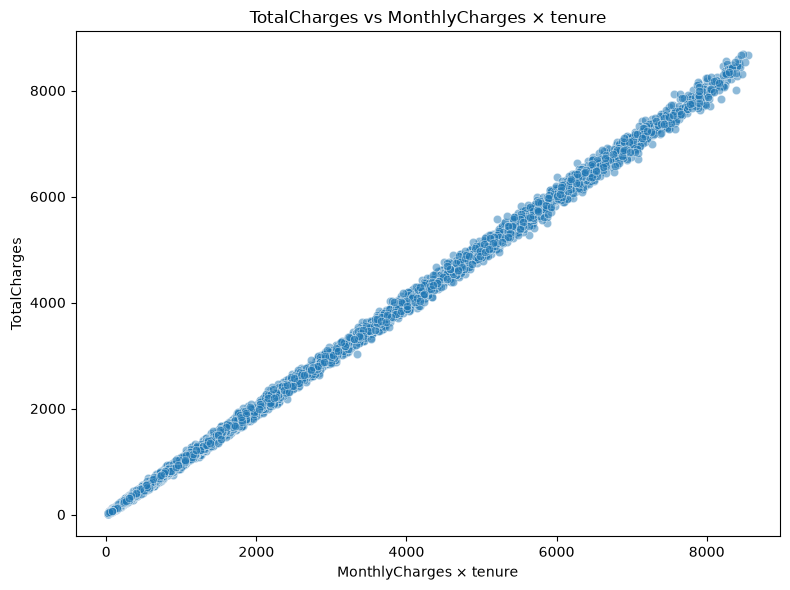

In [12]:
if all(col in df_clean.columns for col in required):
    plot_df = df_clean.copy()
    plot_df["ApproxCharges"] = (
        plot_df["MonthlyCharges"] * plot_df["tenure"]
    )

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x="ApproxCharges",
        y="TotalCharges",
        alpha=0.5
    )

    plt.title("TotalCharges vs MonthlyCharges × tenure")
    plt.xlabel("MonthlyCharges × tenure")
    plt.ylabel("TotalCharges")
    plt.tight_layout()
    plt.show()

 Part D — Categorical Predictors




In [13]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_X.columns.tolist(),
    drop_first=True,
    dtype=float
)

X_encoded = X_encoded.replace(
    [np.inf, -np.inf], np.nan
).dropna()

# Safety check
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(float)

X_encoded = X_encoded.astype(float)

print("Original predictor columns:", X.shape[1])
print("Encoded predictor columns:", X_encoded.shape[1])

display(X_encoded.head())

Original predictor columns: 19
Encoded predictor columns: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.000,1.000,29.850,29.850,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000
1,0.000,34.000,56.950,1889.500,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000
2,0.000,2.000,53.850,108.150,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
3,0.000,45.000,42.300,1840.750,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
4,0.000,2.000,70.700,151.650,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000


13. VIF after One-Hot Encoding


In [17]:
encoded_vif = calculate_vif(X_encoded)

display(encoded_vif.head(20))

,Feature,VIF,Tolerance
0,MultipleLines_No phone service,inf,0.000
1,PhoneService_Yes,inf,0.000
2,InternetService_No,inf,0.000
3,OnlineSecurity_No internet service,inf,0.000
4,DeviceProtection_No internet service,inf,0.000
5,OnlineBackup_No internet service,inf,0.000
6,TechSupport_No internet service,inf,0.000
7,StreamingTV_No internet service,inf,0.000
8,StreamingMovies_No internet service,inf,0.000
9,MonthlyCharges,866.090,0.001


 Part E — Feature Reduction Demonstration


In [15]:
working_X = numeric_X.copy()

history = []

while working_X.shape[1] >= 2:
    current_vif = calculate_vif(working_X)
    highest = current_vif.iloc[0]

    history.append({
        "Removed_or_Stopped": highest["Feature"],
        "Highest_VIF": highest["VIF"]
    })

    if highest["VIF"] <= 5:
        break

    feature_to_remove = highest["Feature"]
    working_X = working_X.drop(columns=[feature_to_remove])

print("VIF after educational feature-reduction demo:")
final_vif = calculate_vif(working_X)
display(final_vif)

print("\nDemo history:")
display(pd.DataFrame(history))

VIF after educational feature-reduction demo:


,Feature,VIF,Tolerance
0,MonthlyCharges,1.121,0.892
1,tenure,1.067,0.937
2,SeniorCitizen,1.053,0.950



Demo history:


,Removed_or_Stopped,Highest_VIF
0,TotalCharges,9.544
1,MonthlyCharges,1.121
